В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [191]:
import pandas as pd
medical_df = pd.read_csv('medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [192]:
non_smoker_df.head()

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


In [193]:
def normal_equations(X, y):
    """Computes the closed-form solution to linear regression"""
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

In [194]:
def get_rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [195]:
def estimate_charges(age, w, b):
    return w * age + b

In [196]:
from scipy.stats import probplot
def show_error_plot(errors):
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.hist(errors)
    plt.subplot(1,2,2)
    probplot(errors, dist='norm', plot=plt)

In [197]:
import numpy as np

X = non_smoker_df["age"]
y = non_smoker_df["charges"]
X_with_intercept = np.c_[np.ones((X.shape[0], 1)), X]

In [198]:
MNK_coefs = normal_equations(X_with_intercept, y)
print(MNK_coefs)

[-2091.42055657   267.24891283]


In [199]:
np.dot(X_with_intercept[0], MNK_coefs)

np.float64(2719.0598743965156)

In [200]:
predictions_MNK = np.dot(X_with_intercept, MNK_coefs)

In [201]:
predictions_MNK

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [202]:
rmse_MNK = get_rmse(y, predictions_MNK)
print(rmse_MNK)

4662.505766636395


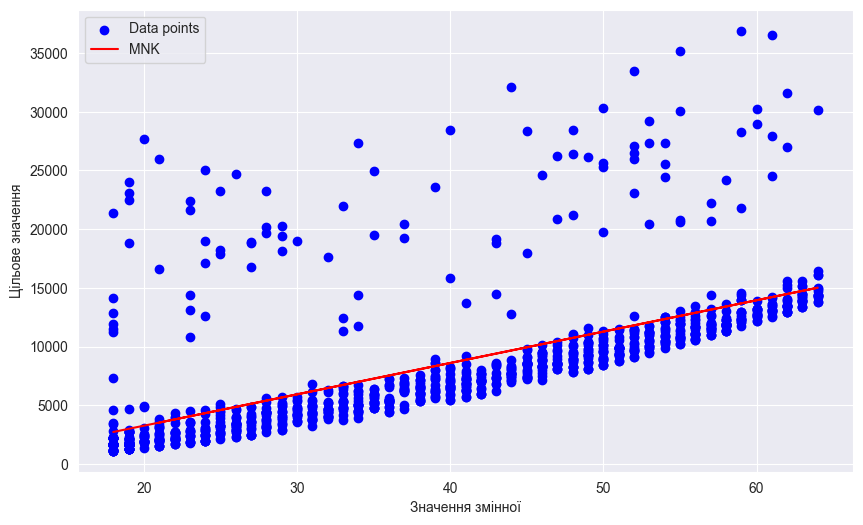

In [203]:
import matplotlib.pyplot as plt
# Візуалізація результатів
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, predictions_MNK, color='red', label='MNK')
plt.xlabel('Значення змінної')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

In [204]:
def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X + b
        error = y_pred - y
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, X)
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

m, b: 262.34481049895373 -1873.6113407966325
MSE: 21744333.810122352
Var(y): 35925420.496111736
RMSE: 4663.082007655704


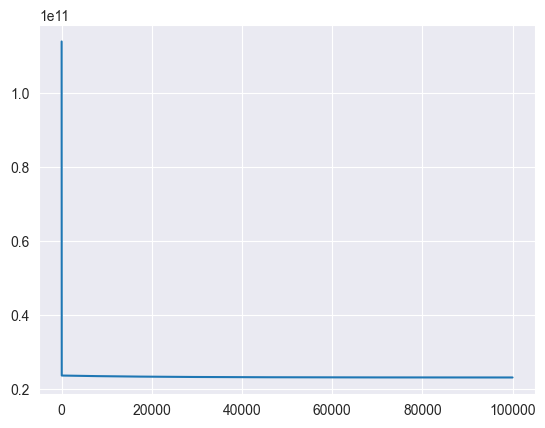

In [205]:
# Case 1. lr = 0.0001
m, b, errors = full_batch_gradient_descent(X, y, lr=0.0001, epochs=100000)
predictions_fbgd_1 = m * X + b
rmse_fbgd = get_rmse(y, predictions_fbgd_1)
mse = np.mean((y - predictions_fbgd_1)**2)
print("m, b:", m, b)
print("MSE:", mse)
print("Var(y):", y.var())
print("RMSE:", rmse_fbgd)

plt.plot(errors)

m, b: 223.14767297767065 -132.72234512002262
MSE: 22173533.21887045
Var(y): 35925420.496111736
RMSE: 4708.878127417448


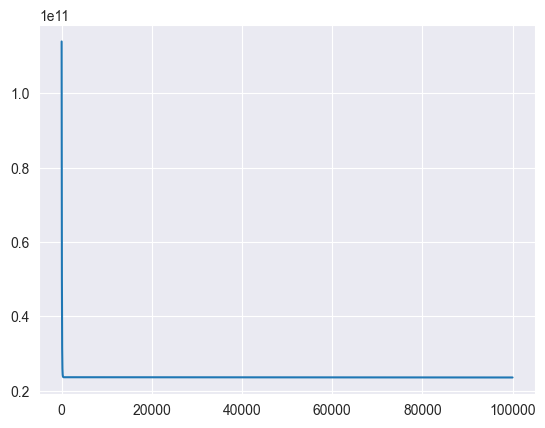

In [206]:
# Case 2. lr = 0.000003
m, b, errors = full_batch_gradient_descent(X, y, lr=0.000003, epochs=100000)
predictions_fbgd_2 = m * X + b
rmse = get_rmse(y, predictions_fbgd_2)
mse = np.mean((y - predictions_fbgd_2)**2)
print("m, b:", m, b)
print("MSE:", mse)
print("Var(y):", y.var())
print("RMSE:", rmse)
plt.plot(errors)

m, b: 221.10457266811318 -41.98074838885027
MSE: 22214731.297909915
Var(y): 35925420.496111736
RMSE: 4713.250608434683


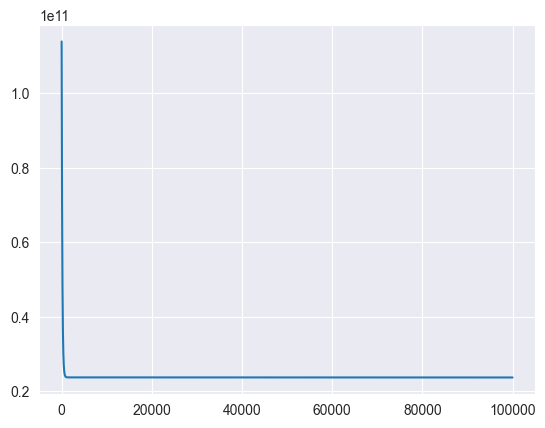

In [207]:
# Case 3. lr = 0.000001
m, b, errors = full_batch_gradient_descent(X, y, lr=0.000001, epochs=100000)
predictions_fbgd_3 = m * X + b
rmse = get_rmse(y, predictions_fbgd_3)
mse = np.mean((y - predictions_fbgd_3)**2)
print("m, b:", m, b)
print("MSE:", mse)
print("Var(y):", y.var())
print("RMSE:", rmse)
plt.plot(errors)

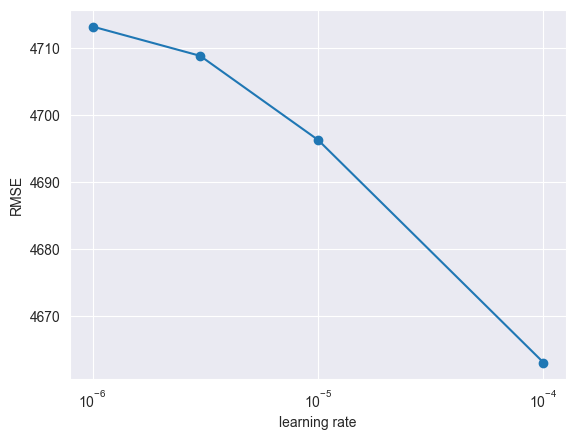

In [208]:
lrs = [0.0001, 0.00001, 0.000003, 0.000001]
rmses = []

for lr in lrs:
    m, b, _ = full_batch_gradient_descent(X, y, lr=lr, epochs=100000)
    rmses.append(np.sqrt(np.mean((m*X + b - y)**2)))

import matplotlib.pyplot as plt
plt.semilogx(lrs, rmses, marker='o')
plt.xlabel("learning rate")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

In [209]:
lrs = [0.0001, 0.00001, 0.000003, 0.000001]
epochs = 100000

for lr in lrs:
    m, b, _ = full_batch_gradient_descent(X, y, lr=lr, epochs=epochs)
    
    y_pred = m * X + b
    mae = np.mean(np.abs(y - y_pred))
    
    rmse = get_rmse(y_pred, y)
    
    print(f"m={m} | b={b} | lr={lr} | MAE={mae:.2f} | RMSE={rmse:.2f}")

m=262.34481049895373 | b=-1873.6113407966325 | lr=0.0001 | MAE=2600.40 | RMSE=4663.08
m=229.61200062335735 | b=-419.8269036279835 | lr=1e-05 | MAE=2756.21 | RMSE=4696.33
m=223.14767297767065 | b=-132.72234512002262 | lr=3e-06 | MAE=2792.21 | RMSE=4708.88
m=221.10457266811318 | b=-41.98074838885027 | lr=1e-06 | MAE=2803.85 | RMSE=4713.25


In [210]:
# Висновок: lr 0.0001 є найкращим, у нього найменший RMSE (4663.08) також він найближчий до МНК (4662.50)

In [211]:
from sklearn.linear_model import LinearRegression

# Модель лінійної регресії засобами Scikit-learn (МНК)
lin_reg = LinearRegression()

In [213]:
lin_reg.fit(X.to_frame(), y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [214]:
lin_reg.coef_, lin_reg.intercept_

(array([267.24891283]), np.float64(-2091.4205565650245))

In [216]:
predictions_sklearn = lin_reg.predict(X.to_frame())

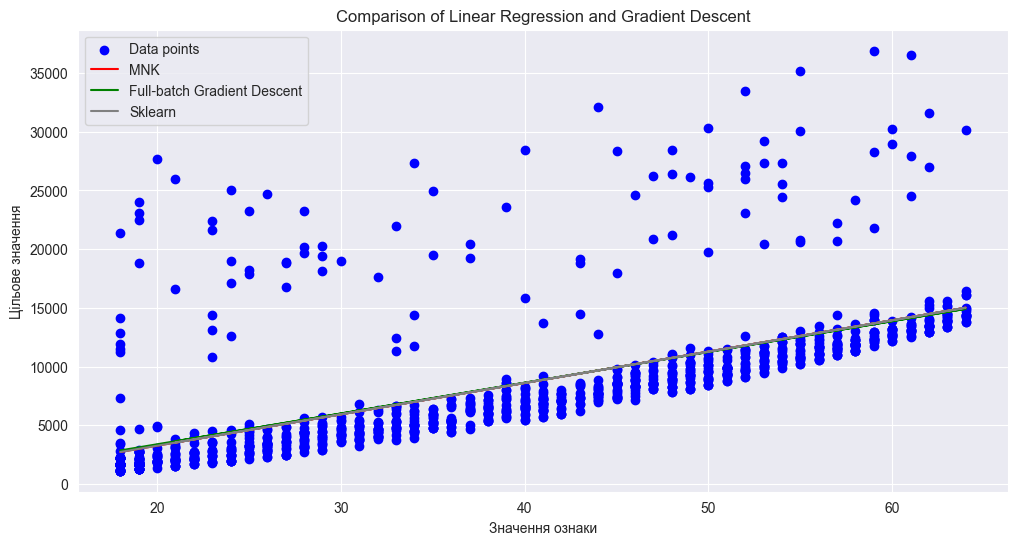

In [217]:
# Візуалізація результатів
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, predictions_MNK, color='red', label='MNK')
plt.plot(X, predictions_fbgd_1, color='green', label='Full-batch Gradient Descent')
plt.plot(X, predictions_sklearn, color='grey', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

In [218]:
from sklearn.metrics import mean_squared_error
import numpy as np
print('RMSE МНК: ', rmse_MNK)
print('RMSE стохаст. град. спуску: ', rmse_fbgd)

rmse_sklearn = np.sqrt(mean_squared_error(y, predictions_sklearn))
print('RMSE sklearn: ', rmse_sklearn)

RMSE МНК:  4662.505766636395
RMSE стохаст. град. спуску:  4663.082007655704
RMSE sklearn:  4662.505766636395


In [219]:
# Усі 3 моделі з порівняння мають практично однакові результати, що підтверджує коректність реалізації. Мій прогноз по RMSE (4769) й близький до вказаних моделей, проте m=200, b=900 вже значно відрізняються від величин розрахованих в моделях.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [220]:
medical_df = pd.read_csv('medical-charges.csv')
smoker_df = medical_df[medical_df.smoker == 'yes']

In [221]:
X = smoker_df["age"]
y = smoker_df["charges"]

In [188]:
# Модель лінійної регресії засобами Scikit-learn (МНК)
lin_reg = LinearRegression()

In [190]:
lin_reg.fit(X.to_frame(), y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [223]:
predictions_sklearn = lin_reg.predict(X.to_frame())

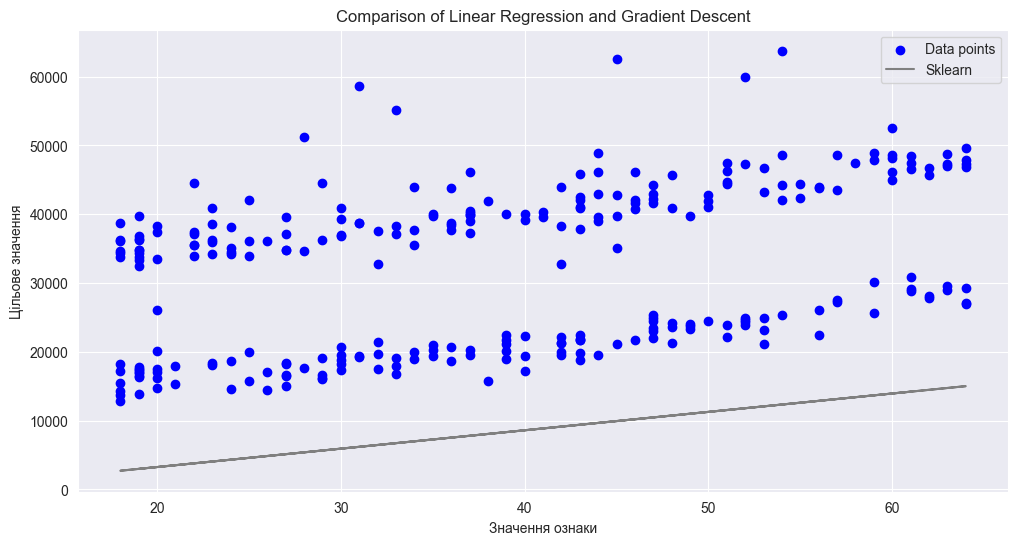

In [224]:
# Візуалізація результатів
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, predictions_sklearn, color='grey', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

In [225]:
rmse_sklearn = np.sqrt(mean_squared_error(y, predictions_sklearn))
print('RMSE smokers sklearn: ', rmse_sklearn)

RMSE smokers sklearn:  26148.867808867617


In [228]:
mae = np.mean(np.abs(y - predictions_sklearn))
print('MAE: ', mae)

MAE:  23848.66780011381


In [226]:
smoker_df.describe()

,age,bmi,children,charges
count,274.000000,274.000000,274.000000,274.000000
mean,38.514599,30.708449,1.113139,32050.231832
std,13.923186,6.318644,1.157066,11541.547176
min,18.000000,17.195000,0.000000,12829.455100
25%,27.000000,26.083750,0.000000,20826.244213
50%,38.000000,30.447500,1.000000,34456.348450
75%,49.000000,35.200000,2.000000,41019.207275
max,64.000000,52.580000,5.000000,63770.428010


In [ ]:
# RMSE суттєво перевищує стандартне відхилення цільової змінної. Ця модель погано прогнозує, оскільки charges для курців більше залежать від інших змінних в датасеті.Також на графіку чітко можна побачити що курці умовно діляться на 2 групи, це вплив додатковї змінної. Лінійна регресія для однієї змінної age не дає можливості коректного прогнозу зборів для курців.